# Laboratorio 2 - Deep Learning

**Integrantes:**

- Flavio Galán
- Josue Say

**Repositorio:**

- [Enlace GitHub](https://github.com/JosueSay/labs-ds/tree/main/lab2)

### Librerías

In [151]:
import pandas as pd
import numpy as np
import pyreadr
import matplotlib.pyplot as plt
import statsmodels.tsa as tsa
import statsmodels as sm
from datetime import datetime
import os
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller
import tensorflow as tf
from sklearn.preprocessing import StandardScaler
from keras.models import Sequential
from keras.layers import Dense
from keras.layers import LSTM
from sklearn.metrics import mean_squared_error, mean_absolute_error
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import pmdarima as pm
from pmdarima.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error
from tabulate import tabulate
from prophet import Prophet
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from keras.layers import Dropout

### Variables - constantes

In [152]:
DATA_DIR = "../data"

REPORTES = "./reportes"
CACHE = "./cache"

# output files
CONSUMO_CSV = f"{DATA_DIR}/consumo_combustibles.csv"
IMPORT_CSV = f"{DATA_DIR}/importacion_combustibles.csv"
PRECIOS_CSV = f"{DATA_DIR}/precios_diarios.csv"
TARGET_COLUMNS = ["fecha", "regular", "superior", "diesel", "glp"]

### Obtención de data

In [153]:
def loadAllData():
    df_consumo = pd.read_csv(CONSUMO_CSV, parse_dates=["fecha"])
    df_importaciones = pd.read_csv(IMPORT_CSV, parse_dates=["fecha"])
    df_precios = pd.read_csv(PRECIOS_CSV, parse_dates=["fecha"])

    print("Datos cargados desde cache CSV.")
    return df_consumo, df_importaciones, df_precios

In [154]:
df_consumo, df_importaciones, df_precios = loadAllData()

Datos cargados desde cache CSV.


## Modelos LSTM para serie de "Precios de Gasolina Regular"

### Constantes

In [155]:
TRAIN_FRACTION = 0.6
VAL_FRACTION = 0.2
TEST_FRACTION = 0.2

### Código para modelos (lab1)

In [156]:
def plotSeries(df, column, title):
    plt.figure(figsize=(10, 5))
    df[column].plot()
    plt.title(title)
    plt.grid(True)
    plt.tight_layout()
    plt.show()

In [157]:
def decomposeSeries(series):
    result = seasonal_decompose(series)
    fig = result.plot()
    fig.set_size_inches(15, 8)
    plt.tight_layout()
    plt.show()

In [158]:
def plotAutocorrelations(series):
    plot_acf(series)
    plt.tight_layout()
    plt.show()
    plot_pacf(series)
    plt.tight_layout()
    plt.show()

In [159]:
def dickeyFullerTest(series):
    print('ADF Test Results')
    dfTest = adfuller(series, autolag='AIC')
    output = pd.Series(dfTest[0:4], index=['Test Statistic','p-value','Lags Used','N Observations'])
    for key, value in dfTest[4].items():
        output[f'Critical Value ({key})'] = value
    print(output)

In [160]:
def splitSeries(series):
    train_size = int(len(series) * TRAIN_FRACTION)
    val_size = int(len(series) * VAL_FRACTION)
    test_size = len(series) - train_size - val_size
    train = series[:train_size]
    val = series[train_size:train_size + val_size]
    test = series[train_size + val_size:]
    return train, val, test

In [161]:
def trainARIMAModels(trainData):
    models = [
        ARIMA(trainData, order=(1,1,1)),
        ARIMA(trainData, order=(0,1,1)),
        ARIMA(trainData, order=(1,1,0))
    ]
    return [model.fit() for model in models]

In [162]:
def plotResiduals(model):
    residuals = model.resid[1:]
    fig, ax = plt.subplots(1, 2, figsize=(14, 5))
    residuals.plot(title="Residuals", ax=ax[0])
    residuals.plot(title="Density", kind="kde", ax=ax[1])
    plt.tight_layout()
    plt.show()

In [163]:
def evaluateARIMAModels(models, testData):
    newDF = pd.DataFrame({'Original': testData})
    newDF = newDF.assign(
        Model_1_1_1=lambda _: list(models[0].forecast(len(testData))),
        Model_0_1_1=lambda _: list(models[1].forecast(len(testData))),
        Model_1_1_0=lambda _: list(models[2].forecast(len(testData))),
        Model_auto=lambda _: list(pm.auto_arima(models[0].data.endog, seasonal=False).predict(len(testData)))
    )
    newDF.plot()
    plt.title("ARIMA Model Predictions")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

In [164]:
def runProphetModel(trainData):
    df_train = pd.DataFrame({"ds": trainData.index, "y": list(trainData)})
    model = Prophet()
    model.fit(df_train)
    future = model.make_future_dataframe(periods=365)
    forecast = model.predict(future)
    model.plot(forecast)
    model.plot_components(forecast)

In [165]:
def runHoltWintersModel(trainData):
    model = ExponentialSmoothing(trainData, trend='add', seasonal='add', seasonal_periods=12)
    fit = model.fit()
    forecast_steps = 6
    predictions = fit.forecast(forecast_steps)
    return predictions

In [166]:
def convertToSupervised(series, nLags=1):
    x, y = [], []
    for i in range(len(series) - nLags):
        x.append(series[i:i + nLags, 0])
        y.append(series[i + nLags, 0])
    return np.array(x), np.array(y)

In [167]:
def runMLPModel(scaledSeries):
    n = len(scaledSeries)
    train_size = int(n * TRAIN_FRACTION)
    val_size = int(n * VAL_FRACTION)

    train = scaledSeries[:train_size]
    val = scaledSeries[train_size:train_size + val_size]
    test = scaledSeries[train_size + val_size:]

    x_train, y_train = convertToSupervised(train, 5)
    x_val, y_val = convertToSupervised(val, 5)
    x_test, y_test = convertToSupervised(test, 5)

    model = MLPRegressor(hidden_layer_sizes=(100, 50), activation='relu', max_iter=1000, early_stopping=True, random_state=1)
    model.fit(x_train, y_train)

    pred_test = model.predict(x_test)
    return pred_test, y_test

In [168]:
def inverseScaleAndEvaluate(predicted, actual, scaler):
    pred_inv = scaler.inverse_transform(np.array(predicted).reshape(-1,1))
    actual_inv = scaler.inverse_transform(np.array(actual).reshape(-1,1))
    rmse = np.sqrt(mean_squared_error(actual_inv, pred_inv))
    mae = mean_absolute_error(actual_inv, pred_inv)
    print(f"RMSE: {rmse:.4f}")
    print(f"MAE: {mae:.4f}")

    plt.figure(figsize=(10,5))
    plt.plot(actual_inv, label='Actual')
    plt.plot(pred_inv, label='Predicted', alpha=0.7)
    plt.title("MLP - Test Set Prediction")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

In [169]:

# === Ejemplo de uso secuencial ===
# df_rango = df_precios["2022":]
# plotSeries(df_rango, "regular", "Precios - regular (2022-2025)")
# decomposeSeries(df_rango["regular"])
# plotAutocorrelations(df_rango["regular"])
# dickeyFullerTest(df_rango["regular"])
# ts_diff = df_rango["regular"].diff().fillna(0)
# dickeyFullerTest(ts_diff)
# train_data, val_data, test_data = splitSeries(ts_diff)
# arima_models = trainARIMAModels(train_data)
# for model in arima_models:
#     plotResiduals(model)
# evaluateARIMAModels(arima_models, test_data)
# runProphetModel(train_data)
# runHoltWintersModel(train_data)

# scaler = StandardScaler()
# ts_diff_scaled = scaler.fit_transform(ts_diff.to_frame())
# pred_test, y_test = runMLPModel(ts_diff_scaled)
# inverseScaleAndEvaluate(pred_test, y_test, scaler)

### Modelos Deep Learning

In [170]:
def preprocessLSTM(series):
    """Aplica diferenciación y escalado"""
    diff = series.diff().fillna(0)
    scaler = MinMaxScaler()
    scaled = scaler.fit_transform(diff.to_frame())
    return diff, scaled, scaler

In [171]:
def seriesToSupervisedLSTM(scaledSeries, n_lags=5):
    """Convierte serie a formato supervisado para LSTM"""
    x, y = [], []
    for i in range(len(scaledSeries) - n_lags):
        x.append(scaledSeries[i:i+n_lags])
        y.append(scaledSeries[i+n_lags])
    x = np.array(x).reshape(-1, n_lags, 1)
    y = np.array(y)
    return x, y

In [172]:
def splitSupervisedLSTM(scaledSeries, n_lags=5):
    """Separa la serie escalada en sets para LSTM"""
    train_size = int(len(scaledSeries) * TRAIN_FRACTION)
    val_size = int(len(scaledSeries) * VAL_FRACTION)
    test_size = len(scaledSeries) - train_size - val_size

    train = scaledSeries[:train_size]
    val = scaledSeries[train_size:train_size+val_size]
    test = scaledSeries[train_size+val_size:]

    x_train, y_train = seriesToSupervisedLSTM(train, n_lags)
    x_val, y_val = seriesToSupervisedLSTM(val, n_lags)
    x_test, y_test = seriesToSupervisedLSTM(test, n_lags)

    return x_train, y_train, x_val, y_val, x_test, y_test

In [173]:
def buildLSTMModel1(n_lags, units=32, optimizer='adam'):
    """Construye el modelo LSTM simple con hiperparámetros"""
    model = Sequential()
    model.add(LSTM(units=units, input_shape=(n_lags, 1)))
    model.add(Dense(1))
    model.compile(loss='mse', optimizer=optimizer)
    return model

In [174]:
def trainAndEvaluateLSTM(x_train, y_train, x_val, y_val, x_test, y_test,
                         model, scaler, original_series, n_lags,
                         epochs=30, batch_size=32, name_model = "LSTM Modelo 1"):
    """Entrena y evalúa el modelo LSTM"""
    history = model.fit(
        x_train, y_train,
        epochs=epochs,
        batch_size=batch_size,
        validation_data=(x_val, y_val),
        verbose=1
    )

    # Gráfica de pérdida
    plt.plot(history.history['loss'], label='train')
    plt.plot(history.history['val_loss'], label='val')
    plt.legend()
    plt.title("LSTM Loss")
    plt.grid(True)
    plt.show()

    # Predicción
    y_pred_scaled = model.predict(x_test)
    y_pred = scaler.inverse_transform(y_pred_scaled)
    y_test_inv = scaler.inverse_transform(y_test)

    # Inversión de la diferenciación
    original = original_series[-(len(y_test_inv) + n_lags):].values
    y_pred_final = y_pred.flatten() + original[n_lags:]
    y_test_final = y_test_inv.flatten() + original[n_lags:]

    # Evaluación
    rmse = np.sqrt(mean_squared_error(y_test_final, y_pred_final))
    mae = mean_absolute_error(y_test_final, y_pred_final)
    print(f"RMSE: {rmse:.4f}")
    print(f"MAE: {mae:.4f}")

    # Gráfico
    fechas = original_series[-len(y_test_final):].index
    plt.figure(figsize=(10, 5))
    plt.plot(fechas, y_test_final, label="Real")
    plt.plot(fechas, y_pred_final, label="Predicción")
    plt.title(name_model)
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

### Preparando la serie

In [175]:
df_rango = df_precios.set_index("fecha")["regular"]["2022":].asfreq("D").fillna(method="ffill")
ts_diff, ts_scaled, scaler = preprocessLSTM(df_rango)
x_train, y_train, x_val, y_val, x_test, y_test = splitSupervisedLSTM(ts_scaled, n_lags=5)

C:\Users\josue\AppData\Local\Temp\ipykernel_36812\193738183.py:1: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df_rango = df_precios.set_index("fecha")["regular"]["2022":].asfreq("D").fillna(method="ffill")


#### Hiperparámetros

In [176]:
param_grid = [
    {"units": 32, "batch_size": 16, "epochs": 30, "optimizer": "adam"},
    {"units": 64, "batch_size": 32, "epochs": 50, "optimizer": "adam"},
    {"units": 64, "batch_size": 16, "epochs": 40, "optimizer": "rmsprop"},
    {"units": 128, "batch_size": 32, "epochs": 60, "optimizer": "adam"},
]

#### Tuneando el modelo


=== Modelo 1 ===
Units: 32, Batch: 16, Epochs: 30, Optimizer: adam
Epoch 1/30


d:\repositorios\UVG\2025\labs-ds\lab2\.venv\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


49/49 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.1161 - val_loss: 0.0014
Epoch 2/30
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0046 - val_loss: 8.4378e-04
Epoch 3/30
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0050 - val_loss: 8.4366e-04
Epoch 4/30
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0045 - val_loss: 8.2769e-04
Epoch 5/30
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0049 - val_loss: 8.3137e-04
Epoch 6/30
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0036 - val_loss: 8.6127e-04
Epoch 7/30
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0048 - val_loss: 8.3188e-04
Epoch 8/30
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0045 - val_loss: 8.2420e-04
Epoch 9/30
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0033 - val_loss: 0.0011
Epoch 10/30
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0050 - val_loss: 8.3870e-04
Epoch 11/30
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0040 - val_loss: 9.1683e-04
Epoch 12/30
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/ste

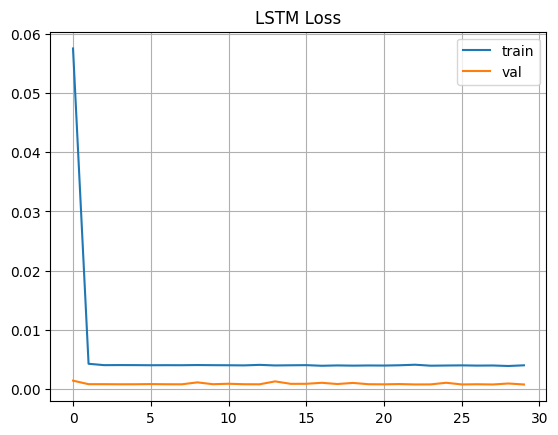

8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
RMSE: 0.1827
MAE: 0.0677


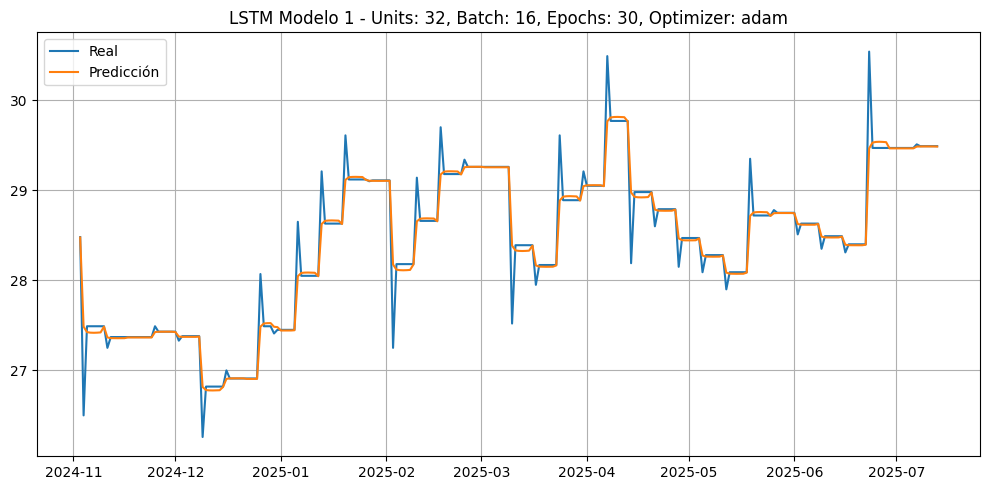


=== Modelo 2 ===
Units: 64, Batch: 32, Epochs: 50, Optimizer: adam
Epoch 1/50


d:\repositorios\UVG\2025\labs-ds\lab2\.venv\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.1722 - val_loss: 8.6212e-04
Epoch 2/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0061 - val_loss: 0.0016
Epoch 3/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0050 - val_loss: 9.0195e-04
Epoch 4/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0043 - val_loss: 9.2583e-04
Epoch 5/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0048 - val_loss: 8.2162e-04
Epoch 6/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0037 - val_loss: 8.4084e-04
Epoch 7/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0040 - val_loss: 8.2952e-04
Epoch 8/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0035 - val_loss: 9.1181e-04
Epoch 9/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0040 - val_loss: 8.3581e-04
Epoch 10/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0051 - val_loss: 8.3744e-04
Epoch 11/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0056 - val_loss: 8.9069e-04
Epoch 12/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms

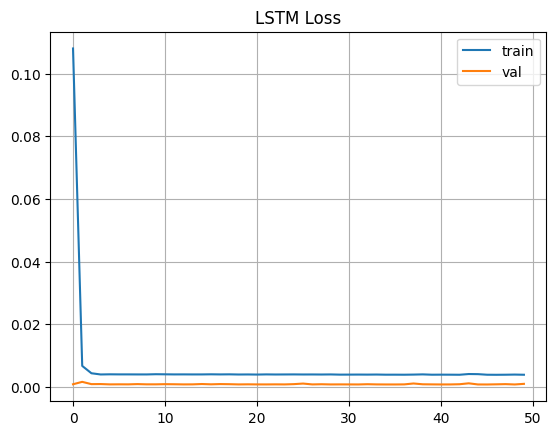

8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
RMSE: 0.2047
MAE: 0.1364


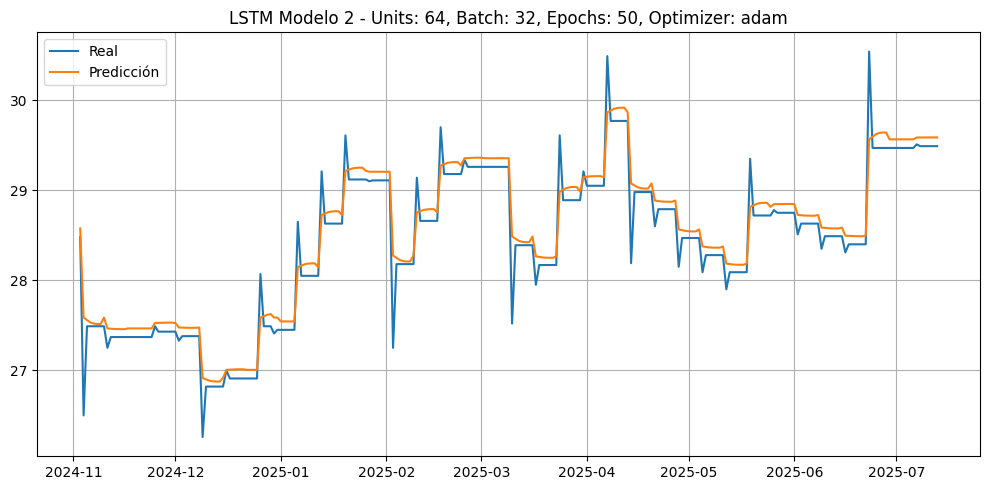


=== Modelo 3 ===
Units: 64, Batch: 16, Epochs: 40, Optimizer: rmsprop
Epoch 1/40


d:\repositorios\UVG\2025\labs-ds\lab2\.venv\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


49/49 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0560 - val_loss: 0.0021
Epoch 2/40
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0049 - val_loss: 0.0013
Epoch 3/40
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0039 - val_loss: 9.9172e-04
Epoch 4/40
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0046 - val_loss: 0.0012
Epoch 5/40
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0043 - val_loss: 0.0011
Epoch 6/40
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0043 - val_loss: 8.2538e-04
Epoch 7/40
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0037 - val_loss: 8.3047e-04
Epoch 8/40
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0062 - val_loss: 8.0803e-04
Epoch 9/40
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0056 - val_loss: 8.1049e-04
Epoch 10/40
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0051 - val_loss: 8.0375e-04
Epoch 11/40
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0036 - val_loss: 0.0012
Epoch 12/40
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.

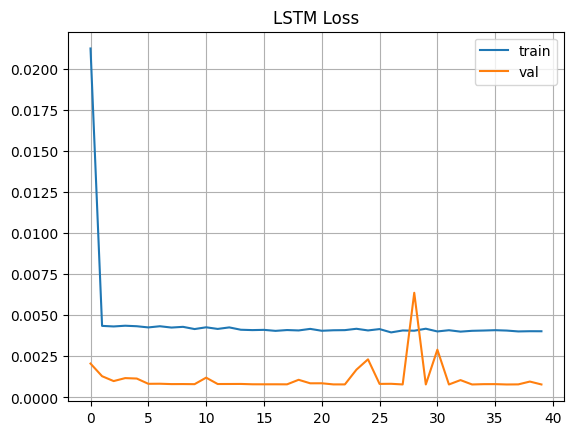

8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
RMSE: 0.1815
MAE: 0.0633


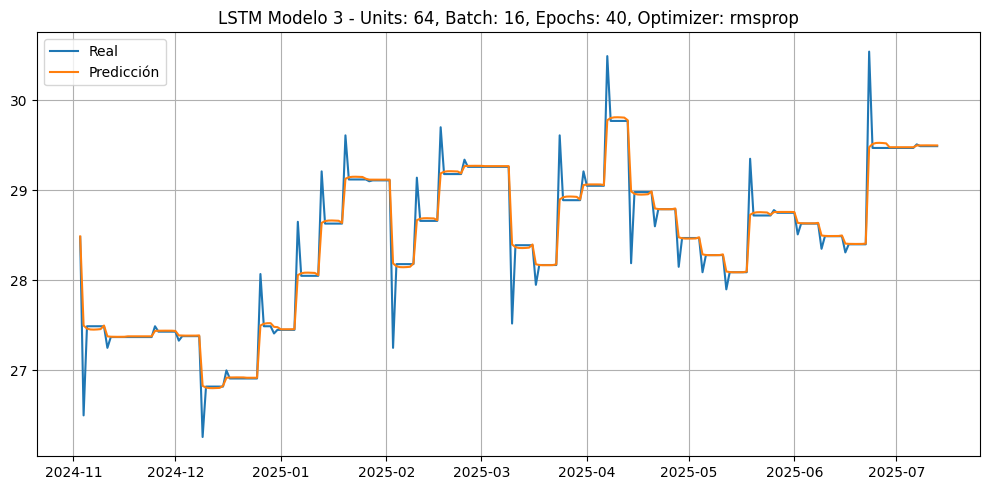


=== Modelo 4 ===
Units: 128, Batch: 32, Epochs: 60, Optimizer: adam
Epoch 1/60


d:\repositorios\UVG\2025\labs-ds\lab2\.venv\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0906 - val_loss: 0.0012
Epoch 2/60
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0072 - val_loss: 0.0018
Epoch 3/60
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0043 - val_loss: 8.5612e-04
Epoch 4/60
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0034 - val_loss: 8.5039e-04
Epoch 5/60
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0041 - val_loss: 8.5383e-04
Epoch 6/60
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0048 - val_loss: 8.5550e-04
Epoch 7/60
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0036 - val_loss: 8.9111e-04
Epoch 8/60
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0046 - val_loss: 9.7147e-04
Epoch 9/60
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0031 - val_loss: 8.5073e-04
Epoch 10/60
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0034 - val_loss: 9.0602e-04
Epoch 11/60
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0058 - val_loss: 8.7168e-04
Epoch 12/60
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/ste

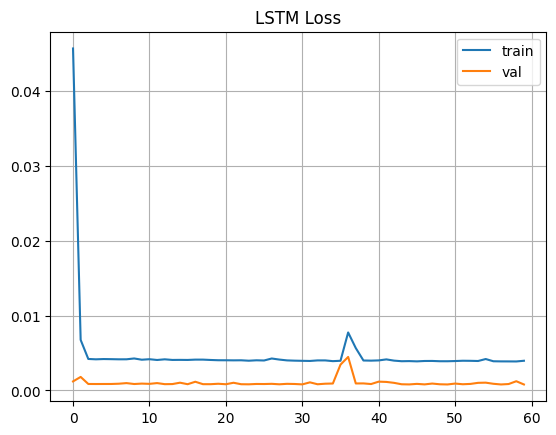

8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
RMSE: 0.1821
MAE: 0.0640


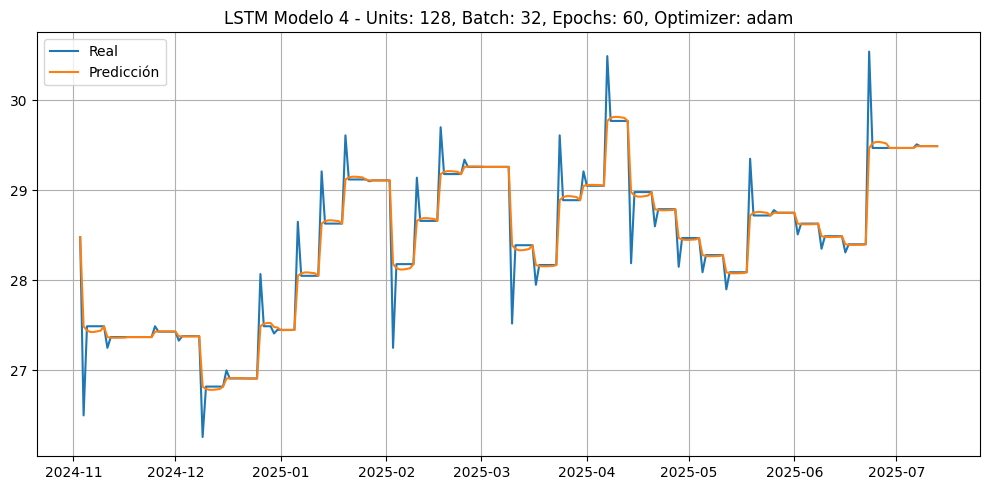

In [177]:
for i, params in enumerate(param_grid, 1):
    print(f"\n=== Modelo {i} ===")
    print(f"Units: {params['units']}, Batch: {params['batch_size']}, Epochs: {params['epochs']}, Optimizer: {params['optimizer']}")
    
    model = buildLSTMModel1(n_lags=5, units=params["units"], optimizer=params["optimizer"])
    
    trainAndEvaluateLSTM(
        x_train, y_train,
        x_val, y_val,
        x_test, y_test,
        model,
        scaler,
        df_rango,
        n_lags=5,
        epochs=params["epochs"],
        batch_size=params["batch_size"],
        name_model=f"LSTM Modelo {i} - Units: {params['units']}, Batch: {params['batch_size']}, Epochs: {params['epochs']}, Optimizer: {params['optimizer']}"
    )

In [178]:
def buildLSTMModel2(n_lags, units=64, dropout_rate=0.2, optimizer='adam'):
    """Construye un modelo LSTM más profundo con Dropout"""
    model = Sequential()
    model.add(LSTM(units=units, return_sequences=True, input_shape=(n_lags, 1)))
    model.add(Dropout(dropout_rate))
    model.add(LSTM(units=units))
    model.add(Dropout(dropout_rate))
    model.add(Dense(1))
    model.compile(loss='mse', optimizer=optimizer)
    return model

In [179]:
param_grid_model2 = [
    {"units": 32, "batch_size": 16, "epochs": 30, "optimizer": "adam", "dropout": 0.2},
    {"units": 64, "batch_size": 32, "epochs": 50, "optimizer": "adam", "dropout": 0.3},
    {"units": 64, "batch_size": 16, "epochs": 40, "optimizer": "rmsprop", "dropout": 0.25},
    {"units": 128, "batch_size": 32, "epochs": 60, "optimizer": "adam", "dropout": 0.2},
]


=== Modelo LSTM 2 - Configuración 1 ===
Units: 32, Batch: 16, Epochs: 30, Optimizer: adam, Dropout: 0.2
Epoch 1/30


d:\repositorios\UVG\2025\labs-ds\lab2\.venv\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


49/49 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.1158 - val_loss: 0.0032
Epoch 2/30
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0065 - val_loss: 8.1796e-04
Epoch 3/30
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0069 - val_loss: 8.1107e-04
Epoch 4/30
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0062 - val_loss: 0.0013
Epoch 5/30
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0068 - val_loss: 9.8051e-04
Epoch 6/30
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0076 - val_loss: 8.0155e-04
Epoch 7/30
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0047 - val_loss: 0.0011
Epoch 8/30
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0079 - val_loss: 8.9840e-04
Epoch 9/30
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0051 - val_loss: 0.0015
Epoch 10/30
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0065 - val_loss: 7.9335e-04
Epoch 11/30
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0055 - val_loss: 8.2665e-04
Epoch 12/30
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss

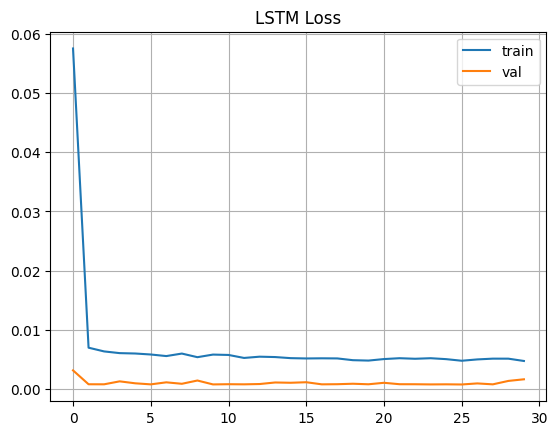

8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
RMSE: 0.2834
MAE: 0.2433


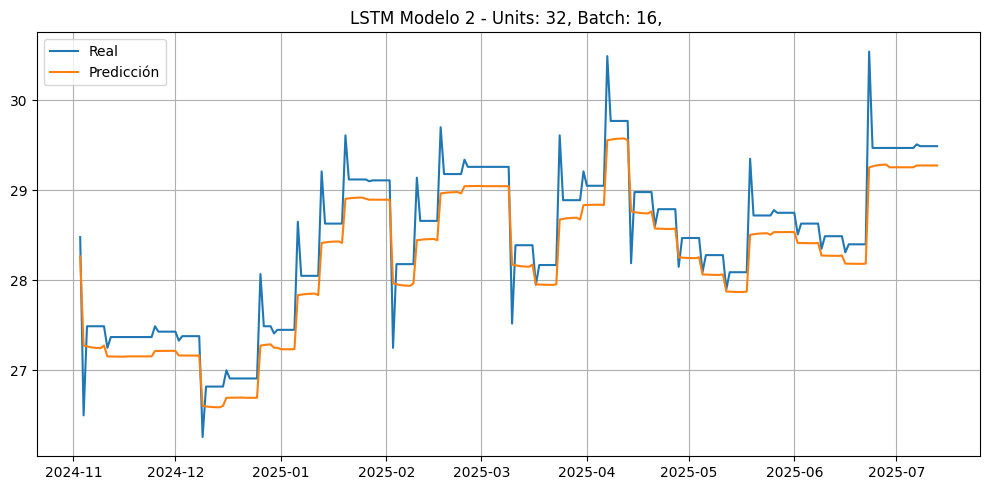


=== Modelo LSTM 2 - Configuración 2 ===
Units: 64, Batch: 32, Epochs: 50, Optimizer: adam, Dropout: 0.3
Epoch 1/50


d:\repositorios\UVG\2025\labs-ds\lab2\.venv\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.1091 - val_loss: 0.0011
Epoch 2/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0093 - val_loss: 0.0010
Epoch 3/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0060 - val_loss: 0.0012
Epoch 4/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0074 - val_loss: 8.3217e-04
Epoch 5/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0069 - val_loss: 8.9293e-04
Epoch 6/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0074 - val_loss: 0.0010
Epoch 7/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0062 - val_loss: 8.2080e-04
Epoch 8/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0058 - val_loss: 8.7994e-04
Epoch 9/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0066 - val_loss: 0.0015
Epoch 10/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0059 - val_loss: 8.1878e-04
Epoch 11/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0062 - val_loss: 8.9736e-04
Epoch 12/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0

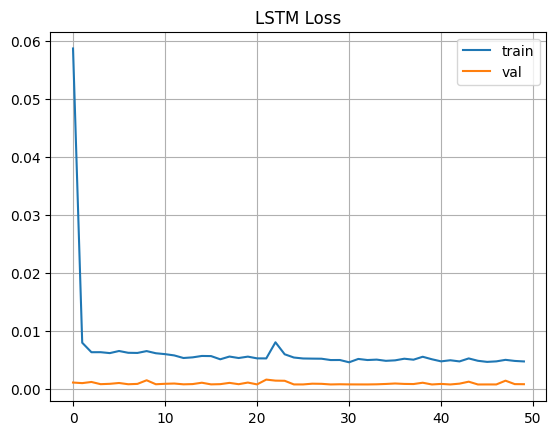

8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
RMSE: 0.1899
MAE: 0.0970


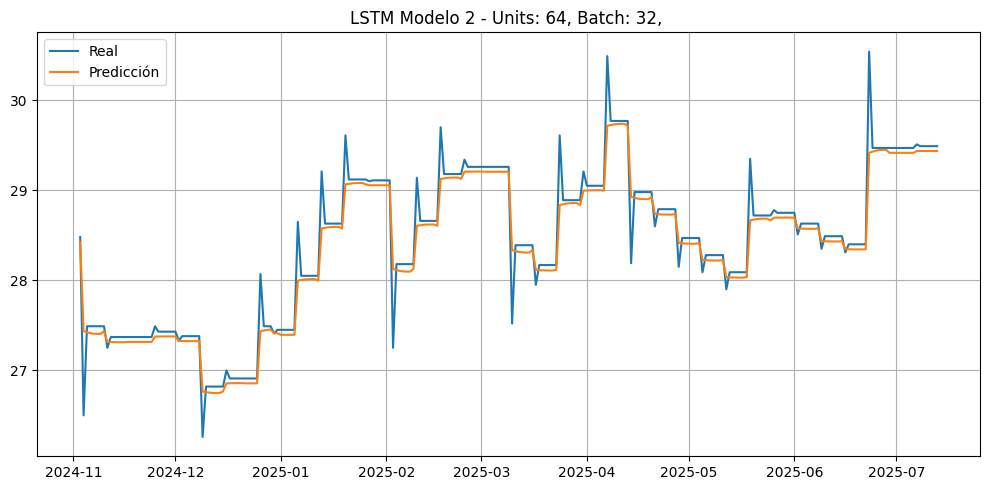


=== Modelo LSTM 2 - Configuración 3 ===
Units: 64, Batch: 16, Epochs: 40, Optimizer: rmsprop, Dropout: 0.25
Epoch 1/40


d:\repositorios\UVG\2025\labs-ds\lab2\.venv\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


49/49 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0558 - val_loss: 0.0035
Epoch 2/40
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0061 - val_loss: 0.0105
Epoch 3/40
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0073 - val_loss: 8.4789e-04
Epoch 4/40
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0057 - val_loss: 9.0030e-04
Epoch 5/40
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0065 - val_loss: 0.0017
Epoch 6/40
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0051 - val_loss: 8.9625e-04
Epoch 7/40
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0059 - val_loss: 8.1601e-04
Epoch 8/40
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0048 - val_loss: 0.0022
Epoch 9/40
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0054 - val_loss: 7.9587e-04
Epoch 10/40
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0051 - val_loss: 7.8581e-04
Epoch 11/40
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0046 - val_loss: 8.6381e-04
Epoch 12/40
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss

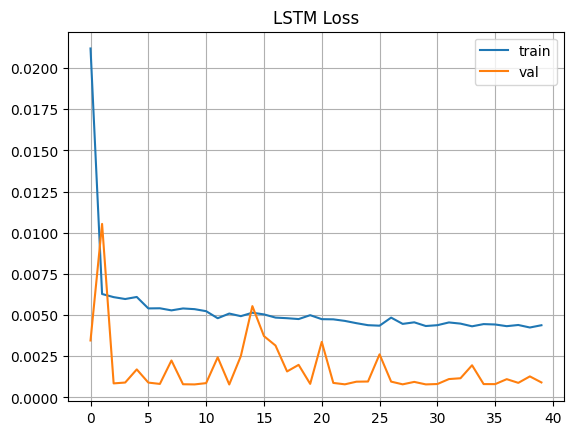

8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
RMSE: 0.2019
MAE: 0.1258


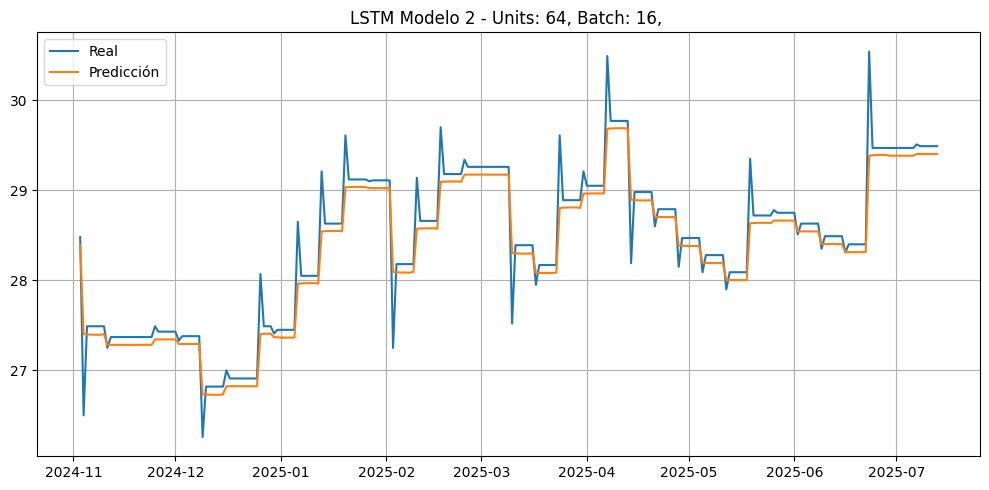


=== Modelo LSTM 2 - Configuración 4 ===
Units: 128, Batch: 32, Epochs: 60, Optimizer: adam, Dropout: 0.2
Epoch 1/60


d:\repositorios\UVG\2025\labs-ds\lab2\.venv\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0881 - val_loss: 0.0059
Epoch 2/60
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0073 - val_loss: 8.6583e-04
Epoch 3/60
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0047 - val_loss: 0.0013
Epoch 4/60
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0053 - val_loss: 8.6062e-04
Epoch 5/60
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0046 - val_loss: 8.3884e-04
Epoch 6/60
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0044 - val_loss: 8.6644e-04
Epoch 7/60
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0042 - val_loss: 8.1594e-04
Epoch 8/60
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0051 - val_loss: 8.1815e-04
Epoch 9/60
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0054 - val_loss: 9.4407e-04
Epoch 10/60
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0051 - val_loss: 0.0010
Epoch 11/60
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0056 - val_loss: 0.0010
Epoch 12/60
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - los

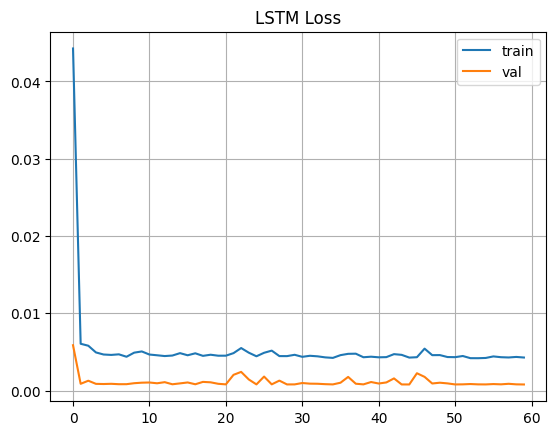

8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
RMSE: 0.1809
MAE: 0.0574


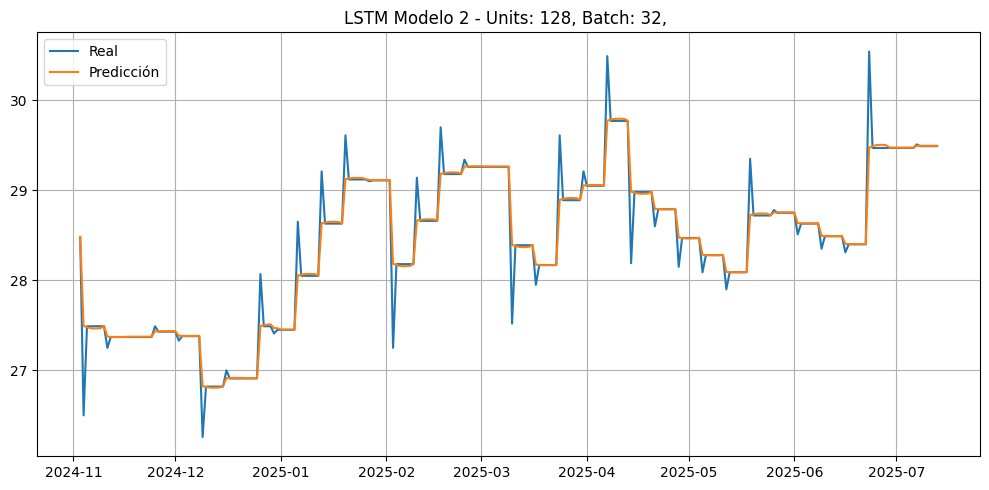

In [180]:
for i, params in enumerate(param_grid_model2, 1):
    print(f"\n=== Modelo LSTM 2 - Configuración {i} ===")
    print(f"Units: {params['units']}, Batch: {params['batch_size']}, Epochs: {params['epochs']}, "
          f"Optimizer: {params['optimizer']}, Dropout: {params['dropout']}")
    
    model = buildLSTMModel2(n_lags=5, units=params["units"],
                            dropout_rate=params["dropout"], optimizer=params["optimizer"])
    
    trainAndEvaluateLSTM(
        x_train, y_train,
        x_val, y_val,
        x_test, y_test,
        model,
        scaler,
        df_rango,
        n_lags=5,
        epochs=params["epochs"],
        batch_size=params["batch_size"],
        name_model=f"LSTM Modelo 2 - Units: {params['units']}, Batch: {params['batch_size']}, "
    )

## OTRA SERIE